In [1]:
import numpy as np
import pandas as pd
from scipy import stats

# 1. Cargamos la base de datos 
df = pd.read_parquet("../inputs/cartera.parquet")

# 2. Filtramos las pólizas que sí tuvieron accidentes (para la severidad)
con = df[df.num_siniestros > 0]
x = con.monto_promedio_siniestro.values

print("Datos cargados correctamente. Pólizas totales:", len(df))

Datos cargados correctamente. Pólizas totales: 30000


In [2]:
# 3. Decisiones de Severidad 
dist_sev = stats.lognorm
pr_sev = dist_sev.fit(x, floc=0) 

# 4. Decisiones de Frecuencia 
lam_hat = 0.0289 
phi = 1.036

print("¡Parámetros listos!")
print(f"La Lognormal guardó {len(pr_sev)} parámetros matemáticos en la memoria.")
print(f"Tasa de frecuencia (lam_hat): {lam_hat} | Sobredispersión (phi): {phi}")

¡Parámetros listos!
La Lognormal guardó 3 parámetros matemáticos en la memoria.
Tasa de frecuencia (lam_hat): 0.0289 | Sobredispersión (phi): 1.036


Siniestros esperados en la cartera (Λ) = 694

Versión          E[S] (prima pura)           VaR99          TVaR99
Ground-up              624,043,273   1,022,281,767   1,284,270,160
Transformada           210,770,078     252,264,510     255,906,457

La póliza (deducible+límite) reduce la prima pura de la cartera un 66.2%: esa es la S que sirve para tarificar el producto.


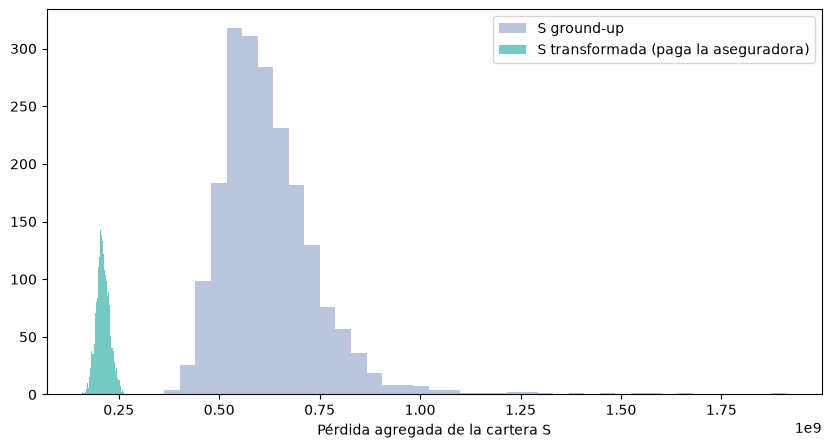

In [5]:
import matplotlib.pyplot as plt

# Función matemática de la póliza (aplica deducible, coaseguro y límite)
def transformar(x, deducible, coaseguro, SA):
    return np.minimum(np.maximum(x - deducible, 0) * (1 - coaseguro), SA)

# ——— Simulación del modelo colectivo (ground-up y transformada) ———
Lambda = lam_hat * df.exposicion.sum()  # siniestros esperados en la cartera
r_agg = Lambda / (phi - 1)              # dispersión agregada (Var = phi * Lambda)
p_agg = r_agg / (r_agg + Lambda)
frecuencia_agg = stats.nbinom(r_agg, p_agg)

ded = df.deducible.values; sa = df.suma_asegurada.values; coas = df.coaseguro.values
M = 2000 # Simulamos 2000 escenarios 
Sg = np.empty(M); Sp = np.empty(M)

for m in range(M):
    Ntot = frecuencia_agg.rvs() # Cuántos choques hubo en el año
    xg = dist_sev.rvs(*pr_sev, size=Ntot) # Cuánto costó cada choque
    pol = np.random.randint(0, len(df), Ntot) # A qué póliza le tocó el choque
    xp = transformar(xg, ded[pol], coas[pol], sa[pol]) # Lo que paga la aseguradora
    
    Sg[m] = xg.sum() # Suma total Ground-up
    Sp[m] = xp.sum() # Suma total Transformada

# ——— Resultados y Gráficas ———
def resumen(S):
    v = np.percentile(S, 99) # VaR al 99%
    return S.mean(), v, S[S > v].mean() # TVaR al 99%

print(f"Siniestros esperados en la cartera (Λ) = {Lambda:,.0f}\n")
print(f"{'Versión':14}{'E[S] (prima pura)':>20}{'VaR99':>16}{'TVaR99':>16}")
for nom, S in [("Ground-up", Sg), ("Transformada", Sp)]:
    e, v, t = resumen(S)
    print(f"{nom:14}{e:>20,.0f}{v:>16,.0f}{t:>16,.0f}")

print(f"\nLa póliza (deducible+límite) reduce la prima pura de la cartera un "
      f"{1 - Sp.mean()/Sg.mean():.1%}: esa es la S que sirve para tarificar el producto.")

# Gráfica
plt.figure(figsize=(10, 5))
plt.hist(Sg, bins=40, alpha=0.6, color="#8FA0C8", label="S ground-up")
plt.hist(Sp, bins=40, alpha=0.6, color="#17A69B", label="S transformada (paga la aseguradora)")
plt.xlabel("Pérdida agregada de la cartera S")
plt.legend()
plt.show()